<a href="https://colab.research.google.com/github/chismithag239-gif/SCT_ML_1/blob/main/SCT_ML_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2  Female   21                  15                      81
2           3  Female   20                  16                       6
3           4    Male   23                  16                      77
4           5  Female   31                  17                      40


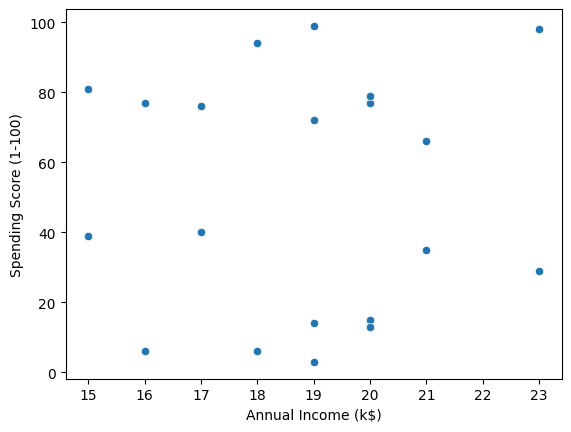

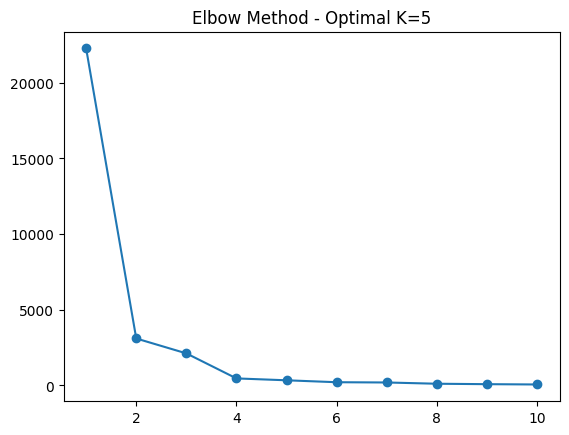

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2  Female   21                  15                      81   
2           3  Female   20                  16                       6   
3           4    Male   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        3  
1        2  
2        1  
3        2  
4        3  
[[20.         97.        ]
 [18.66666667  9.5       ]
 [17.6        78.        ]
 [19.         35.75      ]
 [20.         69.        ]]


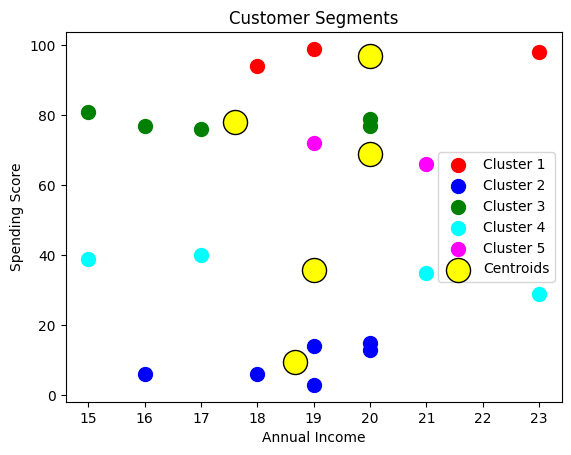

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Sample Mall Customer Data
data = {
    'CustomerID': range(1, 21),
    'Gender': ['Male','Female','Female','Male','Female','Female','Male','Female','Male','Female','Male','Female','Male','Female','Male','Female','Male','Female','Male','Female'],
    'Age': [19,21,20,23,31,22,35,23,64,30,67,35,58,24,37,22,35,20,52,35],
    'Annual Income (k$)': [15,15,16,16,17,17,18,18,19,19,19,19,20,20,20,20,21,21,23,23],
    'Spending Score (1-100)': [39,81,6,77,40,76,6,94,3,72,14,99,15,77,13,79,35,66,29,98]
}
df = pd.DataFrame(data)
print(df.head())

# EDA
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.show()

# Elbow Method
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method - Optimal K=5')
plt.show()

# Final Model - 5 Clusters
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)
print(df.head())
print(kmeans.cluster_centers_)

# Visualization
colors = ['red','blue','green','cyan','magenta']
for i in range(5):
    plt.scatter(X.values[df['Cluster']==i, 0], X.values[df['Cluster']==i, 1], s=100, c=colors[i], label=f'Cluster {i+1}')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=300, c='yellow', edgecolor='black', label='Centroids')
plt.title('Customer Segments')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()